In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [61]:
df=pd.read_csv(r"C:\Users\risla\OneDrive\Desktop\data_hut\Task 2\products_clean.csv")
df.head()

Full_price_products= df.loc[df['Discount_Amount']==0]
Discounted_products= df.loc[df['Discount_Amount']>0]

on_sale_percentage =round(((len(Discounted_products)/len(df))*100),2)


print(f"Share of catalogue on sale: {on_sale_percentage}%")




Share of catalogue on sale: 83.14%



- The catalogue contains **1,607** products.
- **1,336** products (83.14%) are currently discounted.
- Only **271** products (16.86%) are sold at full price.
- This suggests Adidas is running promotions across a significant portion of its online catalogue.



### Distribution of discount_pct


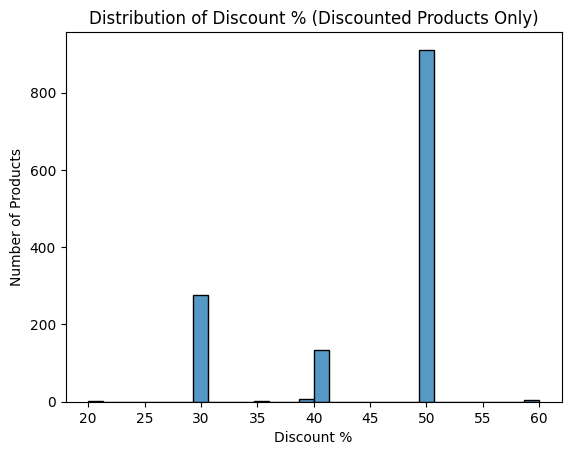

In [96]:

sns.histplot(Discounted_products['Discount_pct'], bins=30)
plt.title('Distribution of Discount % (Discounted Products Only)')
plt.xlabel('Discount %')
plt.ylabel('Number of Products')
plt.savefig("discount_distribution.png")
plt.show()



In [64]:
Discounted_products['Discount_pct'].value_counts().sort_index()


Discount_pct
20.00      1
29.98      5
29.99     46
30.00    225
35.00      3
39.99      6
40.00    135
50.00    911
59.99      4
Name: count, dtype: int64

- The discount percentages are **not uniformly distributed** across the catalogue.
- Most discounted products are concentrated around a few standard discount levels, particularly **50%**, followed by **30%** and **40%**.
- The `value_counts()` output shows that **50%** is the dominant promotional tier with **911 products**, while **30%** and **40%** account for **225** and **135** products, respectively.
- A small number of products have values such as **29.99%** and **39.99%**, which are likely caused by price calculations and rounding rather than separate discount strategies.
- This pattern suggests that Adidas follows a **structured discounting strategy** using predefined promotional slabs instead of assigning random discount percentages.



In [65]:
print("MRP Statistics")
print(df['MRP'].describe())

print("\n Sale Price Statistics")
print(df['Sale_price'].describe())

print("\n Discount % Statistics (discounted only) ")
print(Discounted_products['Discount_pct'].describe())



MRP Statistics
count     1607.000000
mean      6767.886123
std       3597.931146
min        999.000000
25%       4599.000000
50%       5599.000000
75%       7999.000000
max      34999.000000
Name: MRP, dtype: float64

 Sale Price Statistics
count     1607.000000
mean      4413.455507
std       3282.904042
min        649.500000
25%       2399.500000
50%       3179.500000
75%       5499.500000
max      34999.000000
Name: Sale_price, dtype: float64

 Discount % Statistics (discounted only) 
count    1336.000000
mean       44.786183
std         8.218921
min        20.000000
25%        40.000000
50%        50.000000
75%        50.000000
max        59.990000
Name: Discount_pct, dtype: float64


- Average MRP is ₹6,768 but average sale price is ₹4,413 — a gap of ₹2,355, showing heavy discounting across the catalogue.
- Median discount is 50% and the 75th percentile is also 50% — meaning at least half of all discounted products are at the maximum promotional tier.
- MRP has high spread (std dev ₹3,598) indicating multiple distinct price tiers from budget (₹999) to luxury (₹34,999).



In [79]:
sub_brand_summary = df.groupby("Sub_brand").agg(Total_Products=("Sub_brand", "count"),Avg_MRP=('MRP','mean'), Median_discount=('Discount_pct','median'))

sub_brand_summary["Avg_MRP"] = sub_brand_summary["Avg_MRP"].round(2)
sub_brand_summary["Median_discount"] = sub_brand_summary["Median_discount"].round(2)

sub_brand_summary



,Total_Products,Avg_MRP,Median_discount
Sub_brand,,,
Men Originals,103,10237.83,30.00
Men Performance,688,6565.13,50.00
Men Sportswear,433,5988.61,50.00
Men TERREX,66,5195.97,50.00
Originals,81,10685.42,29.99
Performance,145,7892.10,30.00
Sportswear,90,3942.33,35.00
TERREX,1,3999.00,0.00


In [78]:
sub_brand_summary["Discounted_Products"] = (df[df["Discount_pct"] > 0].groupby("Sub_brand").size())

sub_brand_summary["Share_on_Discount"] = round((sub_brand_summary["Discounted_Products"]/sub_brand_summary["Total_Products"] ) * 100,2)

sub_brand_summary = sub_brand_summary.fillna({"Discounted_Products": 0,"Share_on_Discount": 0}).sort_values(by=["Median_discount","Share_on_Discount"],ascending=False)
sub_brand_summary



,Total_Products,Avg_MRP,Median_discount,Discounted_Products,Share_on_Discount
Sub_brand,,,,,
Men TERREX,66,5195.97,50.00,62.0,93.94
Men Performance,688,6565.13,50.00,624.0,90.70
Men Sportswear,433,5988.61,50.00,370.0,85.45
Sportswear,90,3942.33,35.00,64.0,71.11
Performance,145,7892.10,30.00,104.0,71.72
Men Originals,103,10237.83,30.00,70.0,67.96
Originals,81,10685.42,29.99,42.0,51.85
TERREX,1,3999.00,0.00,0.0,0.00


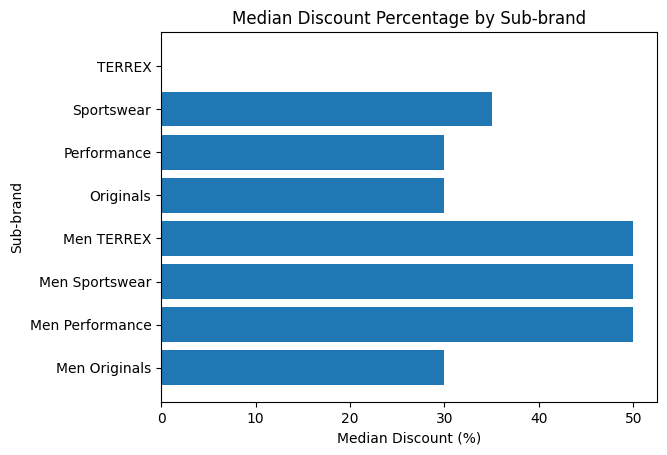

In [97]:
plt.barh(
    sub_brand_summary.index,
    sub_brand_summary["Median_discount"]
)

plt.title("Median Discount Percentage by Sub-brand")
plt.xlabel("Median Discount (%)")
plt.ylabel("Sub-brand")
plt.savefig("subbrand_discount.png")
plt.show()


- The median discount percentage varies across Adidas sub-brands, indicating different promotional strategies.
- **Men Performance**, **Men Sportswear**, and **Men TERREX** have the highest median discount of **50%**, making them the most aggressively discounted segments in the catalogue.
- **Sportswear** has a median discount of **35%**, while **Originals**, **Men Originals**, and **Performance** have median discounts of approximately **30%**, indicating relatively lower promotional intensity.
- The summary table also shows that **Men TERREX** has the highest share of products on discount (93.94%), followed by **Men Performance** (90.70%). This suggests that most products in these categories are currently being sold at discounted prices.
- **Originals** and **Men Originals** have higher average MRPs but comparatively lower median discounts. This may suggest that Adidas maintains stronger pricing for its lifestyle and heritage product lines, while performance-oriented products appear to be promoted more aggressively.
- These findings indicate different pricing strategies across sub-brands. However, the dataset only reflects the current catalogue and cannot determine the exact business reasons behind Adidas's pricing decisions.


In [72]:
df['Price_Tier']=pd.qcut(df['MRP'],q=4,labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
df

,Title,Product_link,Sub_brand,Sale_price,MRP,Discount_Amount,Discount_pct,Price_Tier
0,Samba OG Shoes,https://www.adidas.co.in/samba-og-shoes/B75806...,Originals,10999.0,10999.0,0.0,0.00,Q4 (High)
1,Samba OG Shoes,https://www.adidas.co.in/samba-og-shoes/B75807...,Originals,10999.0,10999.0,0.0,0.00,Q4 (High)
2,Galaxy 7 Running Shoes,https://www.adidas.co.in/galaxy-7-running-shoe...,Men Performance,4409.5,6299.0,1889.5,30.00,Q3
3,PURECHILL SLIDES,https://www.adidas.co.in/purechill-slides/KI00...,Men Sportswear,6599.0,6599.0,0.0,0.00,Q3
4,Adizero EVO SL Shoes,https://www.adidas.co.in/adizero-evo-sl-shoes/...,Men Performance,15999.0,15999.0,0.0,0.00,Q4 (High)
...,...,...,...,...,...,...,...,...
1602,Aero Sprint Spark Shoes,https://www.adidas.co.in/aero-sprint-spark-sho...,Performance,2399.5,4799.0,2399.5,50.00,Q2
1603,Spinyy Sneaker,https://www.adidas.co.in/spinyy-sneaker/JK8338...,Men Sportswear,3299.5,6599.0,3299.5,50.00,Q3
1604,Aquo Slip On Slides,https://www.adidas.co.in/aquo-slip-on-slides/J...,Sportswear,959.5,1599.0,639.5,39.99,Q1 (Low)
1605,Aero Sprint Spark Shoes,https://www.adidas.co.in/aero-sprint-spark-sho...,Performance,2879.5,4799.0,1919.5,40.00,Q2


In [73]:
df["Price_Tier"].value_counts()

Price_Tier
Q1 (Low)     451
Q2           398
Q4 (High)    392
Q3           366
Name: count, dtype: int64

In [84]:
Price_Tier_summary = df.groupby("Price_Tier").agg(Total_Products=("Price_Tier", "count"),Avg_MRP=('MRP','mean'), Median_discount=('Discount_pct','median'),Avg_discount=('Discount_pct','mean'))

Price_Tier_summary["Avg_MRP"] = Price_Tier_summary["Avg_MRP"].round(2)
Price_Tier_summary["Median_discount"] = Price_Tier_summary["Median_discount"].round(2)
Price_Tier_summary["Avg_discount"] = Price_Tier_summary["Avg_discount"].round(2)

Price_Tier_summary


,Total_Products,Avg_MRP,Median_discount,Avg_discount
Price_Tier,,,,
Q1 (Low),451,3684.59,50.0,39.06
Q2,398,5174.63,50.0,42.86
Q3,366,6718.95,50.0,37.62
Q4 (High),392,11978.59,30.0,29.06


In [90]:
correlation = df["MRP"].corr(df["Discount_pct"])
print(f"Correlation between MRP and Discount %: {correlation:.2f}")

Correlation between MRP and Discount %: -0.25


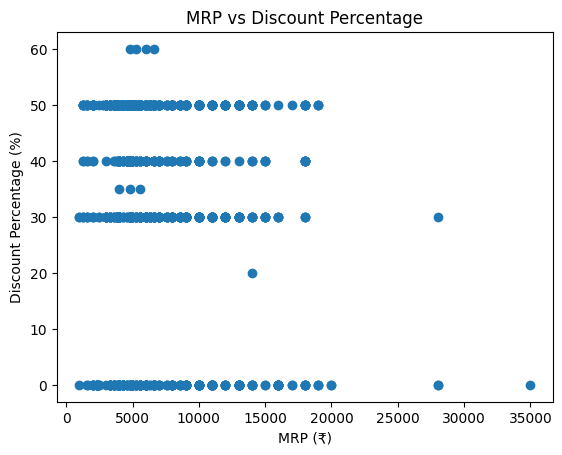

In [98]:
plt.scatter(df["MRP"], df["Discount_pct"])

plt.title("MRP vs Discount Percentage")
plt.xlabel("MRP (₹)")
plt.ylabel("Discount Percentage (%)")
plt.savefig("mrp_vs_discount.png")
plt.show()


- Products were grouped into four price tiers using **MRP quartiles** to compare discount behaviour across different price levels.
- The lower and mid-priced tiers (**Q1–Q3**) have a median discount of **50%**, while the premium tier (**Q4**) has a lower median discount of **30%**.
- The correlation between **MRP** and **Discount Percentage** is **-0.25**, indicating a **weak negative relationship**.
- The scatter plot supports this finding, showing that higher-priced products generally receive smaller percentage discounts, although the trend is not strong.
- Overall, premium shoes tend to receive lower percentage discounts, but **price alone does not strongly determine Adidas's discounting strategy**.

In [93]:
q1 = df.groupby("Sub_brand")["Discount_pct"].transform(lambda x: x.quantile(0.25))
q3 = df.groupby("Sub_brand")["Discount_pct"].transform(lambda x: x.quantile(0.75))

iqr = q3 - q1

lower_limit = q1 - (1.5 * iqr)
upper_limit = q3 + (1.5 * iqr)

df["Flag"] = "Normal"

df.loc[df["Discount_pct"] < lower_limit, "Flag"] = "Unusually Low Discount"
df.loc[df["Discount_pct"] > upper_limit, "Flag"] = "Unusually High Discount"


pricing_outliers = df[df["Flag"] != "Normal"]


pricing_outliers = pricing_outliers[
    [
        "Title",
        "Sub_brand",
        "MRP",
        "Sale_price",
        "Discount_pct",
        "Flag"
    ]
]

pricing_outliers

# pricing_outliers.to_csv(
#     "pricing_outliers.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

,Title,Sub_brand,MRP,Sale_price,Discount_pct,Flag
3,PURECHILL SLIDES,Men Sportswear,6599.0,6599.0,0.0,Unusually Low Discount
4,Adizero EVO SL Shoes,Men Performance,15999.0,15999.0,0.0,Unusually Low Discount
8,PURECHILL SLIDES,Men Sportswear,4999.0,4999.0,0.0,Unusually Low Discount
10,PURECHILL SLIDES,Men Sportswear,4999.0,4999.0,0.0,Unusually Low Discount
12,PURECHILL SLIDES,Men Sportswear,6599.0,6599.0,0.0,Unusually Low Discount
...,...,...,...,...,...,...
1485,Bise Pro Top Flip Flops,Men Sportswear,999.0,999.0,0.0,Unusually Low Discount
1486,BlazeAir Shoes,Men Performance,4799.0,4799.0,0.0,Unusually Low Discount
1490,ADISTAR 4 RUNNING SHOES,Men Performance,13999.0,13999.0,0.0,Unusually Low Discount
1508,Zapid Shoes,Men Performance,4999.0,4999.0,0.0,Unusually Low Discount


In [95]:
print(pricing_outliers['Sub_brand'].value_counts())

Sub_brand
Men Performance    64
Men Sportswear     63
Men TERREX          4
Name: count, dtype: int64



- Using the IQR method within each sub-brand, **131 products** were identified as pricing outliers. All of these were **full-price products (0% discount)** within sub-brands where most products were discounted.
- These outliers may represent **new arrivals** that have not yet been included in promotional campaigns, or **hero/premium products** that are intentionally kept at full price to maintain brand value.
- The current dataset does not contain information such as product launch dates or promotional history, so these explanations cannot be confirmed. Therefore, these products should be considered **items for further review rather than pricing errors**.